In [299]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("minahilfatima12328/car-sales-info")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\dsapu\.cache\kagglehub\datasets\minahilfatima12328\car-sales-info\versions\1


In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer

In [301]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from torch import nn
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import pytorch_optimizer as optim1
import optuna

from pytorch_lightning import LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
import pytorch_lightning as pl
from torchmetrics.regression import R2Score, MeanSquaredError, MeanAbsoluteError
from torchmetrics.functional import r2_score, mean_squared_error, mean_absolute_error
pl.seed_everything(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

Seed set to 42


device(type='cpu')

In [302]:
df = pd.read_csv('car_sales_data.csv')
df

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


In [303]:
X = df.drop(columns='Price', axis=1)
y = df.Price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 6), (10000, 6), (40000,), (10000,))

In [304]:
df.isnull().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

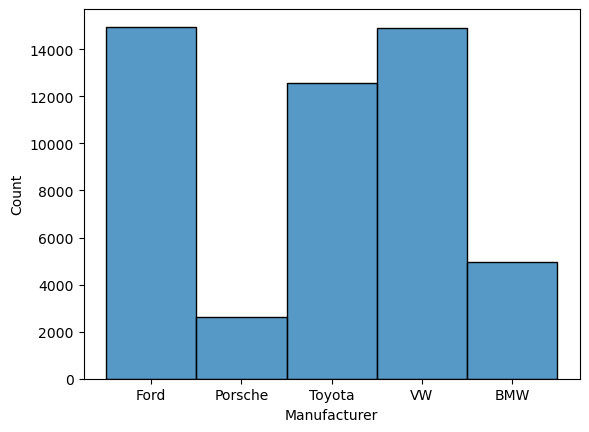

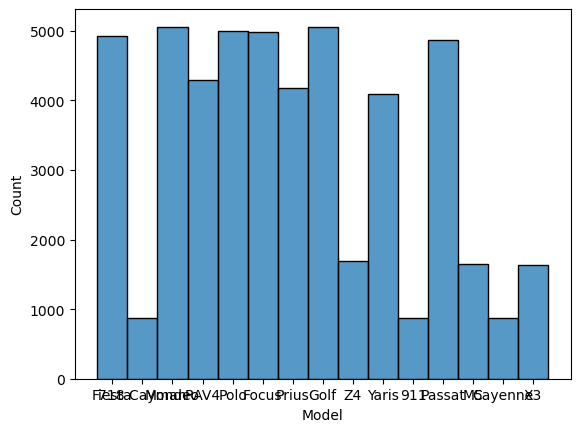

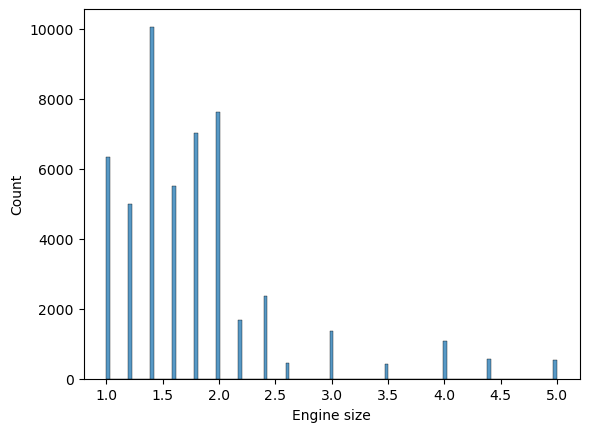

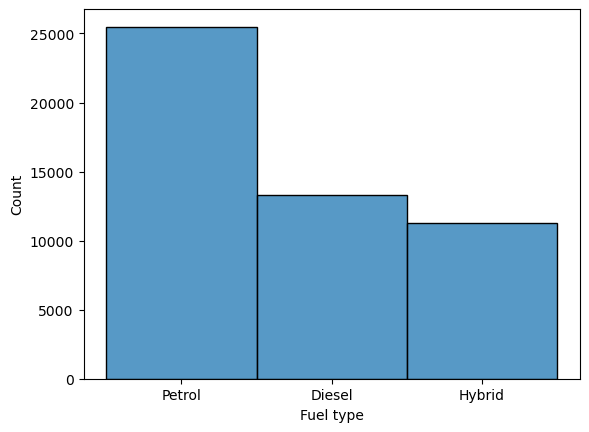

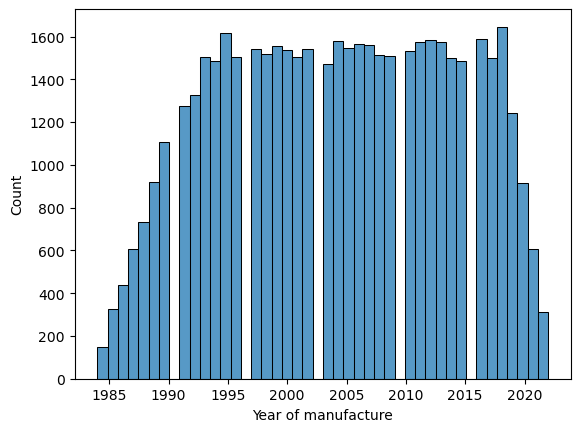

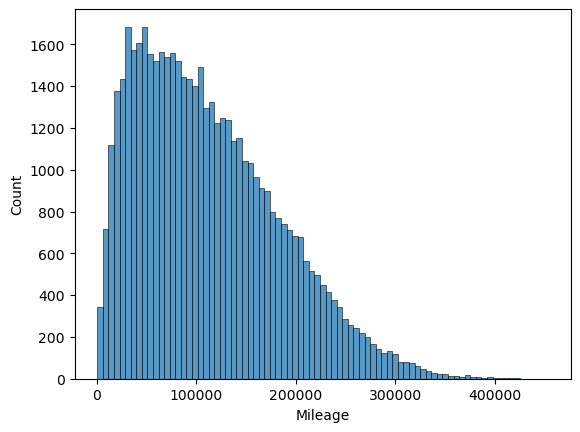

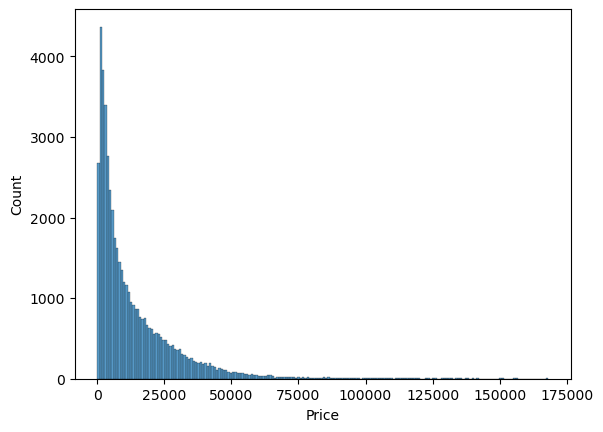

In [305]:
for i in df.columns:
    sns.histplot(df[i])
    plt.show()


In [306]:
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


(None,
   Manufacturer       Model  Engine size Fuel type  Year of manufacture  \
 0         Ford      Fiesta          1.0    Petrol                 2002   
 1      Porsche  718 Cayman          4.0    Petrol                 2016   
 2         Ford      Mondeo          1.6    Diesel                 2014   
 3       Toyota        RAV4          1.8    Hybrid                 1988   
 4           VW        Polo          1.0    Petrol                 2006   
 
    Mileage  Price  
 0   127300   3074  
 1    57850  49704  
 2    39190  24072  
 3   210814   1705  
 4   127869   4101  )

In [307]:
cat = [i for i in X_train.columns if X_train[i].dtype == 'object']
num = [i for i in X_train.columns if i not in cat]
num, cat

(['Engine size', 'Year of manufacture', 'Mileage'],
 ['Manufacturer', 'Model', 'Fuel type'])

In [308]:
num_pipe = Pipeline([
    ('power', PowerTransformer()),
    ('Std', StandardScaler())
])
cat_pipe = Pipeline([
    ('ohe', OneHotEncoder())
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num),
    ('cat', cat_pipe, cat)
]
)
X_train_pipe = preprocessor.fit_transform(X_train)
X_test_pipe = preprocessor.transform(X_test)
fno = preprocessor.get_feature_names_out()
print(X_train_pipe.shape)
X_train_pipe = X_train_pipe.toarray()
X_test_pipe = X_test_pipe.toarray()
X_train_visual = pd.DataFrame(data=X_train_pipe, index=X_train.index, columns=fno)

(40000, 26)


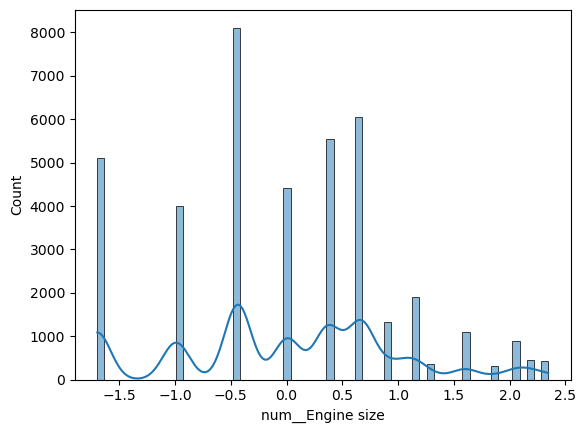

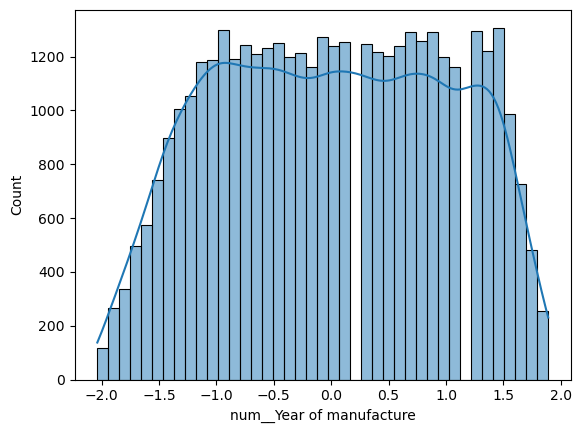

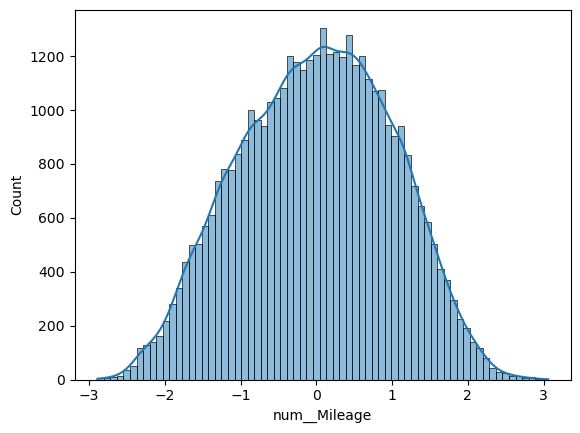

In [309]:
for i in num:
    sns.histplot(X_train_visual[f'num__{i}'], kde=True)
    plt.show()

In [310]:
X_train = torch.tensor(X_train_pipe, dtype=torch.float32)
X_test = torch.tensor(X_test_pipe, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)

train_set = TensorDataset(X_train, y_train)
trainloader = DataLoader(train_set, batch_size=128, shuffle=True)

test_set = TensorDataset(X_test, y_test)
testloader = DataLoader(test_set, batch_size=128, shuffle=False)

In [311]:
feature, target = next(iter(trainloader))
feature.shape, target.shape

(torch.Size([128, 26]), torch.Size([128]))

In [ ]:
class NN(nn.Module):
    def __init__(self, input_size, num_classes) -> None:
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.Mish(),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.Mish(),
            # nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.Mish(),
            # nn.Dropout(0.1),

            nn.Linear(8, 8),
            nn.BatchNorm1d(8),
            nn.Mish(),
            # nn.Dropout(0.1),

            # nn.Linear(8, 8),
            # nn.BatchNorm1d(8),
            # nn.Mish(),
            # nn.Dropout(0.1),

            nn.Linear(8, 1)
        )

    def forward(self, X):
        return self.fc(X)

In [ ]:
class PLNN(LightningModule):
    def __init__(self, input_size, num_classes=4, learning_rate=5e-3):
        super().__init__()
        self.save_hyperparameters() 
        self.model = NN(input_size=input_size, num_classes=num_classes)
        self.criterion = nn.MSELoss()
        self.r2 = R2Score()
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        outputs = outputs.squeeze() 
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)

        
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_r2', r2, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        outputs = outputs.squeeze() 
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)


        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_r2', r2, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        outputs = outputs.squeeze() 
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)


        self.log('test_loss', loss, on_epoch=True, prog_bar=True)
        self.log('test_r2', r2, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim1.AdamW(self.parameters(), lr=self.hparams.learning_rate)
        return optimizer

In [ ]:
if torch.cuda.is_available():
    accelerator_type = 'gpu'
    devices_to_use = 1
else:
    accelerator_type = 'cpu'
    devices_to_use = 'auto'

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath='checkpoints/',
    filename='carsale-{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    mode='min'
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=200,
    mode='min',
)
lr_monitor_callback = LearningRateMonitor(logging_interval='epoch')

trainer1 = pl.Trainer(
    max_epochs=300,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor_callback],
    logger=TensorBoardLogger("tb_logs", name="simple_model_experiment"),
    accelerator=accelerator_type,
    devices=devices_to_use,
    log_every_n_steps=10,
    deterministic=True,
    enable_progress_bar=True
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [315]:
model = PLNN(input_size=X_train.shape[1], num_classes=1, learning_rate=1e-3)
trainer1.fit(model, trainloader, testloader)


  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | model     | NN      | 2.7 K  | train
1 | criterion | MSELoss | 0      | train
2 | r2        | R2Score | 0      | train
----------------------------------------------
2.7 K     Trainable params
0         Non-trainable params
2.7 K     Total params
0.011     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [316]:
trainer1.validate(model, testloader)

Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │         7588497.0         │
│          val_r2           │    0.9721521735191345     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 7588497.0, 'val_r2': 0.9721521735191345}]